In [192]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Features:
- Price Ratio: ClosePrice / OriginalListPrice
    - Measures negotiation strength
- Price Per Sq Ft: ClosePrice / LivingArea
    - Normalizes price across sizes
- Days on Market: DaysonMarket (raw field)
    - Time-to-sell indicator
- Year / Month / YrMo: Derived from CloseDate
    - Enables time-series analysis
- Close to Original List Ratio: ClosePrice / OriginalListPrice
    - Captures full price reduction history
- Listing to Contract Days: PurchaseContractDate - ListingContractDate
    - Measures time from listing to accepted offer
- Contract to Close Days: CloseDate - PurchaseContractDate
    - Escrow and closing period duration

In [193]:
listings_cleaned_df = pd.read_csv("../data/Listing/listings_cleaned.csv")
listings_cleaned_df.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,price_ratio,price_per_sqft,Month,YrMo,CloseToOriginalListRatio,ListingToContractDays,ContractToCloseDays
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,False,False,False,NaN,NaN,NaN,NaN,NaN,127 days,NaN
2,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [194]:
listings_cleaned_df['price_ratio'] = listings_cleaned_df['ClosePrice'] / listings_cleaned_df['OriginalListPrice']
listings_cleaned_df[listings_cleaned_df['price_ratio'].notna()].head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,price_ratio,price_per_sqft,Month,YrMo,CloseToOriginalListRatio,ListingToContractDays,ContractToCloseDays
10,1249888.0,1073295259,sandra.mcfetridge@gmail.com,2024-05-01,1262555.0,Sandra,McFetridge,33.477414,-117.664879,33450 Paseo El Lazo,...,False,False,False,1.010135,664.852554,5.0,2024-05,1.010135,20 days,73 days
17,650000.0,1073219502,lorijo@tcsn.net,2024-03-15,650000.0,Lori Jo,Stribling,35.508840,-120.690614,5405 San Benito Road,...,False,False,False,1.000000,464.285714,3.0,2024-03,1.000000,10 days,43 days
21,1025000.0,1073169832,doug@socalmodern.com,2024-05-02,962500.0,Douglas,Kramer,33.812886,-118.097004,3108 Kallin Avenue,...,False,False,False,0.939024,851.769912,5.0,2024-05,0.939024,104 days,2 days
23,725000.0,1073164974,zachmickelson1@gmail.com,2024-04-30,725000.0,Zachary,Mickelson,33.740706,-117.888816,505 S Spruce Street,...,False,False,False,1.000000,580.000000,4.0,2024-04,1.000000,18 days,81 days
46,730000.0,1071104851,Antonio@AntonioMatier.com,2024-04-09,730000.0,Antonio,Matier,NaN,NaN,2456 Havenscourt Blvd,...,False,False,False,1.000000,576.619273,4.0,2024-04,1.000000,35 days,58 days


In [195]:
listings_cleaned_df.shape

(809907, 70)

In [196]:
listings_cleaned_df['price_per_sqft'] = listings_cleaned_df['ClosePrice'] / listings_cleaned_df['LivingArea']
listings_cleaned_df[listings_cleaned_df['price_per_sqft'].notna()].head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,price_ratio,price_per_sqft,Month,YrMo,CloseToOriginalListRatio,ListingToContractDays,ContractToCloseDays
10,1249888.0,1073295259,sandra.mcfetridge@gmail.com,2024-05-01,1262555.0,Sandra,McFetridge,33.477414,-117.664879,33450 Paseo El Lazo,...,False,False,False,1.010135,664.852554,5.0,2024-05,1.010135,20 days,73 days
17,650000.0,1073219502,lorijo@tcsn.net,2024-03-15,650000.0,Lori Jo,Stribling,35.508840,-120.690614,5405 San Benito Road,...,False,False,False,1.000000,464.285714,3.0,2024-03,1.000000,10 days,43 days
21,1025000.0,1073169832,doug@socalmodern.com,2024-05-02,962500.0,Douglas,Kramer,33.812886,-118.097004,3108 Kallin Avenue,...,False,False,False,0.939024,851.769912,5.0,2024-05,0.939024,104 days,2 days
23,725000.0,1073164974,zachmickelson1@gmail.com,2024-04-30,725000.0,Zachary,Mickelson,33.740706,-117.888816,505 S Spruce Street,...,False,False,False,1.000000,580.000000,4.0,2024-04,1.000000,18 days,81 days
46,730000.0,1071104851,Antonio@AntonioMatier.com,2024-04-09,730000.0,Antonio,Matier,NaN,NaN,2456 Havenscourt Blvd,...,False,False,False,1.000000,576.619273,4.0,2024-04,1.000000,35 days,58 days


In [197]:
listings_cleaned_df['price_per_sqft'].isna().sum()

np.int64(591466)

In [198]:
listings_cleaned_df[listings_cleaned_df['CloseDate'].notna()]['CloseDate'].head()

10    2024-05-01
17    2024-03-15
21    2024-05-02
23    2024-04-30
46    2024-04-09
Name: CloseDate, dtype: str

In [199]:
listings_cleaned_df['CloseDate'] = pd.to_datetime(listings_cleaned_df['CloseDate'])

In [200]:
listings_cleaned_df['Month'] = listings_cleaned_df['CloseDate'].dt.month

In [201]:
listings_cleaned_df['Month'].isna().sum()

np.int64(568800)

In [202]:
listings_cleaned_df['Year'] = listings_cleaned_df['CloseDate'].dt.year

In [203]:
listings_cleaned_df['Year'].isna().sum()

np.int64(568800)

In [204]:
listings_cleaned_df['CloseDate'].isna().sum()

np.int64(568800)

In [205]:
listings_cleaned_df['YrMo'] = listings_cleaned_df['CloseDate'].dt.to_period('M')

In [206]:
listings_cleaned_df['YrMo'].isna().sum()

np.int64(568800)

In [207]:
listings_cleaned_df[listings_cleaned_df['YrMo'].notna()]['YrMo'].head()

10    2024-05
17    2024-03
21    2024-05
23    2024-04
46    2024-04
Name: YrMo, dtype: period[M]

In [208]:
listings_cleaned_df['CloseToOriginalListRatio'] = listings_cleaned_df['ClosePrice'] / listings_cleaned_df['OriginalListPrice']

In [209]:
listings_cleaned_df['CloseToOriginalListRatio'].isna().sum()

np.int64(591466)

In [210]:
listings_cleaned_df['PurchaseContractDate'] = pd.to_datetime(listings_cleaned_df['PurchaseContractDate'])

In [211]:
listings_cleaned_df['ListingContractDate'] = pd.to_datetime(listings_cleaned_df['ListingContractDate'])

In [212]:
listings_cleaned_df['ListingToContractDays'] = listings_cleaned_df['PurchaseContractDate'] - listings_cleaned_df['ListingContractDate']

In [213]:
listings_cleaned_df['ListingToContractDays'].isna().sum()

np.int64(453269)

In [214]:
listings_cleaned_df[listings_cleaned_df['ListingToContractDays'].notna()]['ListingToContractDays'].head()

1    127 days
9    104 days
10    20 days
11   114 days
15   101 days
Name: ListingToContractDays, dtype: timedelta64[us]

In [215]:
listings_cleaned_df['ContractToCloseDays'] = listings_cleaned_df['CloseDate'] - listings_cleaned_df['PurchaseContractDate']

In [216]:
listings_cleaned_df[listings_cleaned_df['ContractToCloseDays'].notna()]['ContractToCloseDays'].head()

10   73 days
17   43 days
21    2 days
23   81 days
46   58 days
Name: ContractToCloseDays, dtype: timedelta64[us]

In [217]:
listings_cleaned_df['ContractToCloseDays'].isna().sum()

np.int64(575010)

#### **Segment Analysis**

Property Segmentation

In [218]:
property_summary = (
    listings_cleaned_df.groupby(['PropertyType', 'PropertySubType'])
    .agg(
        sales_count=('ClosePrice', 'count'),
        median_close_price=('ClosePrice', 'median'),
        avg_close_price=('ClosePrice', 'mean'),
        avg_price_per_sqft=('price_per_sqft', 'mean'),
        median_dom=('DaysOnMarket', 'median'),
        avg_sale_to_list=('price_ratio', 'mean')
    )
    .reset_index()
)

A. Market Heat Score
- Higher measures mean stronger demand and faster movement

In [219]:
property_summary['market_heat_score'] = (property_summary['avg_sale_to_list'] / property_summary['median_dom'])

In [220]:
property_summary[property_summary['market_heat_score'] != float('inf')]['market_heat_score'].describe()

count    70.000000
mean      2.360778
std      11.615831
min       0.069561
25%       0.111524
50%       0.157400
75%       0.315772
max      74.387139
Name: market_heat_score, dtype: float64

In [221]:
property_summary[property_summary['market_heat_score'] > 72]

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score
27,CommercialSale,UnimprovedLand,1,86000.0,8.600000e+04,53.750000,0.0,0.868687,inf
51,Residential,SingleFamilyResidence,97174,875000.0,1.007104e+06,inf,10.0,inf,inf
62,ResidentialIncome,Duplex,1334,910000.0,1.006161e+06,610.248844,10.0,743.871394,74.387139
84,ResidentialLease,SingleFamilyResidence,37411,4300.0,6.298970e+03,inf,9.0,inf,inf


In [222]:
property_summary[property_summary['market_heat_score'] < 0.07]

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score
48,Residential,MobileHome,25,450000.0,433100.0,inf,13.0,0.904294,0.069561


B. Premium vs. Discount
- Shows whether homes sell above or below asking. 
- Ex: 
    - +3% -> bidding wars
    - -5% -> price negotiation pressure

In [223]:
property_summary['premium_discount_pct'] = ((property_summary['avg_sale_to_list'] - 1) * 100)

In [224]:
property_summary[property_summary['premium_discount_pct'] < 0].head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct
1,BusinessOpportunity,SingleFamilyResidence,20,110000.0,189455.000000,118.409375,6.0,0.765012,0.127502,-23.498771
3,CommercialLease,Business,6,3025.0,3136.833333,1.960521,6.0,0.931481,0.155247,-6.851941
5,CommercialLease,Industrial,10,3147.6,3868.820000,2.418013,1.0,0.857741,0.857741,-14.225867
6,CommercialLease,MixedUse,26,2875.0,3139.730769,1.962332,1.0,0.978934,0.978934,-2.106610
12,CommercialLease,Warehouse,5,5000.0,7258.962000,4.536851,1.0,0.957244,0.957244,-4.275566


In [225]:
property_summary.groupby('PropertyType')['premium_discount_pct'].mean()

PropertyType
BusinessOpportunity     -23.498771
CommercialLease         886.523374
CommercialSale           -7.048242
Land                     23.530134
ManufacturedInPark       16.076684
Residential                    inf
ResidentialIncome      7425.117044
ResidentialLease               inf
Name: premium_discount_pct, dtype: float64

In [226]:
property_summary.nsmallest(1, 'premium_discount_pct')

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct
1,BusinessOpportunity,SingleFamilyResidence,20,110000.0,189455.0,118.409375,6.0,0.765012,0.127502,-23.498771


In [227]:
property_summary[property_summary['premium_discount_pct'] > 0].head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct
7,CommercialLease,Office,36,2200.0,25122.998889,15.701874,1.0,6.679403,6.679403,567.940336
8,CommercialLease,Retail,37,2650.0,28323.797297,17.702373,1.0,64.073580,64.073580,6307.358035
9,CommercialLease,SingleFamilyResidence,97,2950.0,36010.126804,22.495118,5.0,3.443486,0.688697,244.348600
32,Land,SingleFamilyResidence,1284,327500.0,553342.320374,345.838950,8.0,1.758279,0.219785,75.827894
33,Land,WaterPositionWithLand,3,255000.0,515000.000000,321.875000,4.5,1.007545,0.223899,0.754484


In [228]:
property_summary.nlargest(1, 'premium_discount_pct')

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct
51,Residential,SingleFamilyResidence,97174,875000.0,1.007104e+06,inf,10.0,inf,inf,inf


C. Relative Liquity Score
- Lower DOM = more liquid market

In [229]:
property_summary['liquidity_score'] = (
    1 / property_summary['median_dom']
)

In [230]:
property_summary['liquidity_score'].describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    90.000000
mean           inf
std            NaN
min       0.034483
25%       0.100000
50%       0.142857
75%       0.333333
max            inf
Name: liquidity_score, dtype: float64

In [231]:
max_liquidity = property_summary[property_summary['liquidity_score'] != float('inf')]['liquidity_score'].max()
max_liquidity

np.float64(2.0)

In [232]:
property_summary[property_summary['liquidity_score'] == max_liquidity]

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
2,CommercialLease,Agriculture,0,NaN,NaN,NaN,0.5,NaN,NaN,NaN,2.0
77,ResidentialLease,ManufacturedHome,10,1700.0,1820.0,1.695693,0.5,0.958333,1.916667,-4.166667,2.0


Commerical Lease and Residential Lease houses tend to sell faster

In [233]:
min_liquidity = property_summary['liquidity_score'].min()
min_liquidity

np.float64(0.034482758620689655)

In [234]:
property_summary[property_summary['liquidity_score'] == min_liquidity]

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
61,ResidentialIncome,DeededParking,0,NaN,NaN,NaN,29.0,NaN,NaN,NaN,0.034483


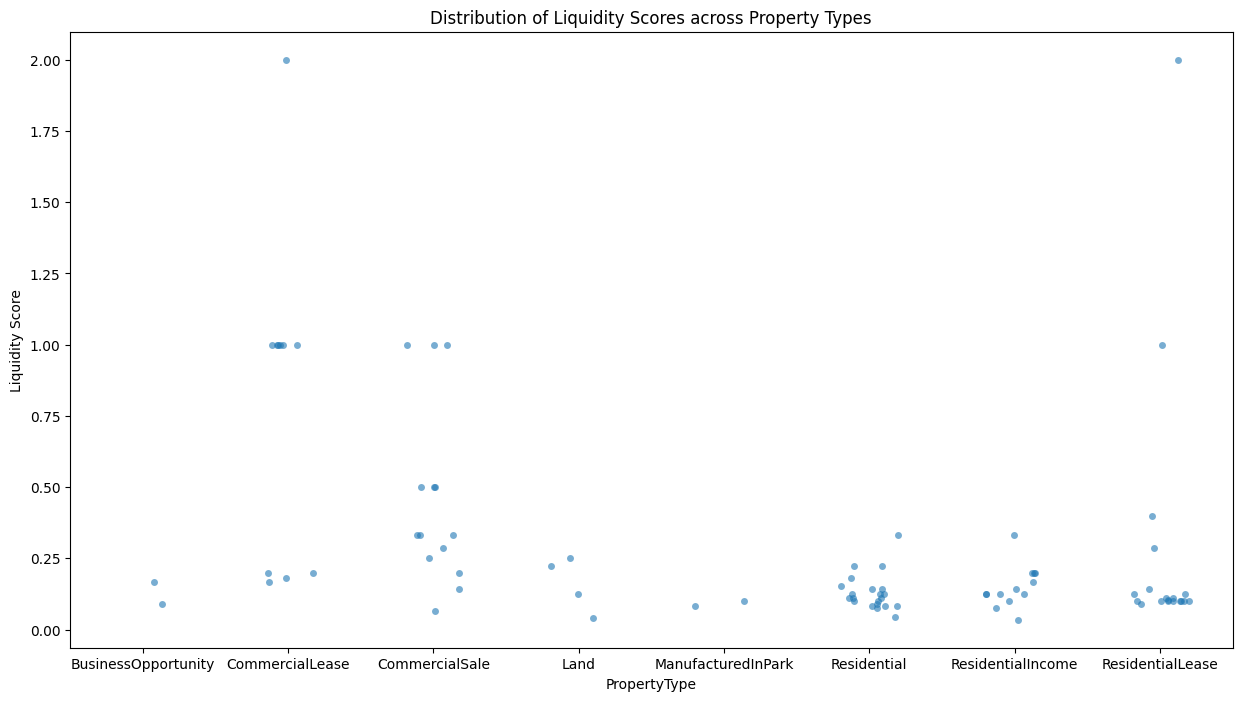

In [235]:
plt.figure(figsize=(15, 8))

sns.stripplot(
    x="PropertyType",
    y="liquidity_score",
    data=property_summary,
    jitter=0.2, 
    alpha=0.6,
)

plt.title("Distribution of Liquidity Scores across Property Types")
plt.ylabel("Liquidity Score")
plt.show()

Most Expensive

In [236]:
expensive_segments = property_summary.sort_values(
    by='median_close_price',
    ascending=False
)
expensive_segments.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
57,ResidentialIncome,Apartment,274,1504144.0,1.524932e+06,953.082505,5.0,0.947906,0.189581,-5.209357,0.200000
28,CommercialSale,Warehouse,4,1500000.0,1.362500e+06,851.562500,2.0,0.999777,0.499889,-0.022282,0.500000
19,CommercialSale,MixedUse,67,1488000.0,1.432924e+06,895.577603,3.0,0.932694,0.310898,-6.730576,0.333333
68,ResidentialIncome,Townhouse,6,1480000.0,1.353167e+06,845.729167,3.0,0.952192,0.317397,-4.780813,0.333333
21,CommercialSale,MultiFamily,14,1362500.0,1.482286e+06,926.428571,3.0,0.909770,0.303257,-9.023034,0.333333


Fastest Selling

In [237]:
faster_segments = property_summary.sort_values(
    by='median_dom',
    ascending=False
)
faster_segments.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
61,ResidentialIncome,DeededParking,0,NaN,NaN,NaN,29.0,NaN,NaN,NaN,0.034483
31,Land,CoOwnership,0,NaN,NaN,NaN,25.0,NaN,NaN,NaN,0.040000
36,Residential,Apartment,0,NaN,NaN,NaN,23.0,NaN,NaN,NaN,0.043478
13,CommercialSale,Agriculture,0,NaN,NaN,NaN,15.5,NaN,NaN,NaN,0.064516
48,Residential,MobileHome,25,450000.0,433100.0,inf,13.0,0.904294,0.069561,-9.570621,0.076923


In [238]:
def classify_market(row):

    if row['market_heat_score'] > 0.02:
        return 'Hot Market'

    elif row['market_heat_score'] > 0.01:
        return 'Balanced'

    else:
        return 'Slow Market'

property_summary['market_category'] = (
    property_summary.apply(classify_market, axis=1)
)

In [239]:
property_summary['market_category'].value_counts()

market_category
Hot Market     73
Slow Market    17
Name: count, dtype: int64

In [240]:
hot_market = property_summary[property_summary['market_category'] == "Hot Market"]
hot_market.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score,market_category
1,BusinessOpportunity,SingleFamilyResidence,20,110000.0,189455.000000,118.409375,6.0,0.765012,0.127502,-23.498771,0.166667,Hot Market
3,CommercialLease,Business,6,3025.0,3136.833333,1.960521,6.0,0.931481,0.155247,-6.851941,0.166667,Hot Market
5,CommercialLease,Industrial,10,3147.6,3868.820000,2.418013,1.0,0.857741,0.857741,-14.225867,1.000000,Hot Market
6,CommercialLease,MixedUse,26,2875.0,3139.730769,1.962332,1.0,0.978934,0.978934,-2.106610,1.000000,Hot Market
7,CommercialLease,Office,36,2200.0,25122.998889,15.701874,1.0,6.679403,6.679403,567.940336,1.000000,Hot Market


In [241]:
hot_market.describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encou

,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
count,73.000000,7.300000e+01,7.300000e+01,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000
mean,2992.342466,4.888132e+05,5.102790e+05,inf,6.527397,inf,inf,inf,inf
std,12544.466774,5.104767e+05,5.101661e+05,NaN,3.501875,NaN,NaN,NaN,NaN
min,1.000000,1.300000e+03,1.489012e+03,1.073066,0.000000,0.765012,0.069561,-23.498771,0.076923
25%,9.000000,3.025000e+03,4.183107e+03,15.701874,3.500000,0.945205,0.112068,-5.479520,0.100000
50%,36.000000,3.250000e+05,3.924636e+05,485.589544,7.000000,0.978934,0.174522,-2.106610,0.142857
75%,436.000000,8.900000e+05,9.660755e+05,804.698551,10.000000,1.020031,0.330543,2.003128,0.285714
max,97174.000000,1.504144e+06,1.524932e+06,inf,13.000000,inf,inf,inf,inf


In [242]:
slow_market = property_summary[property_summary['market_category'] == "Slow Market"]
slow_market.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score,market_category
0,BusinessOpportunity,MixedUse,0,NaN,NaN,NaN,11.0,NaN,NaN,NaN,0.090909,Slow Market
2,CommercialLease,Agriculture,0,NaN,NaN,NaN,0.5,NaN,NaN,NaN,2.000000,Slow Market
4,CommercialLease,Farm,0,NaN,NaN,NaN,5.5,NaN,NaN,NaN,0.181818,Slow Market
11,CommercialLease,UnimprovedLand,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.000000,Slow Market
13,CommercialSale,Agriculture,0,NaN,NaN,NaN,15.5,NaN,NaN,NaN,0.064516,Slow Market


In [243]:
slow_market.describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
count,17.0,0.0,0.0,0.0,17.000000,0.0,0.0,0.0,17.000000
mean,0.0,NaN,NaN,NaN,8.294118,NaN,NaN,NaN,inf
std,0.0,NaN,NaN,NaN,9.622660,NaN,NaN,NaN,NaN
min,0.0,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.034483
25%,0.0,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.076923
50%,0.0,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,0.250000
75%,0.0,NaN,NaN,NaN,13.000000,NaN,NaN,NaN,1.000000
max,0.0,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,inf


In [244]:
# Group by property type, calculate the median of the close price, and find the maximum value
max_mean_price = property_summary.groupby('PropertyType')['avg_close_price'].max()
max_mean_price.sort_values(ascending=False)

PropertyType
ResidentialIncome      1.524932e+06
CommercialSale         1.482286e+06
Residential            1.238859e+06
Land                   6.465417e+05
ManufacturedInPark     2.509149e+05
BusinessOpportunity    1.894550e+05
CommercialLease        3.601013e+04
ResidentialLease       6.298970e+03
Name: avg_close_price, dtype: float64

In [245]:
# Group by property type, calculate the median of the close price, and find the maximum value
max_median_price = property_summary.groupby('PropertyType')['median_close_price'].max()
max_median_price.sort_values(ascending=False).head()

PropertyType
ResidentialIncome     1504144.0
CommercialSale        1500000.0
Residential           1235000.0
Land                   649500.0
ManufacturedInPark     240000.0
Name: median_close_price, dtype: float64

In [246]:
max_sales = property_summary.groupby('PropertyType')['sales_count'].max()
max_sales.sort_values(ascending=False)

PropertyType
Residential            97174
ResidentialLease       37411
ManufacturedInPark      4152
ResidentialIncome       1375
Land                    1284
CommercialSale           194
CommercialLease           97
BusinessOpportunity       20
Name: sales_count, dtype: int64

In [247]:
# Group by property subtype, calculate the mean of the close price, and find the maximum value
max_mean_price = property_summary.groupby('PropertySubType')['avg_close_price'].max()
max_mean_price.sort_values(ascending=False).head()

PropertySubType
Apartment      1.524932e+06
MultiFamily    1.482286e+06
MixedUse       1.432924e+06
Warehouse      1.362500e+06
Townhouse      1.353167e+06
Name: avg_close_price, dtype: float64

In [248]:
# Group by property subtype, calculate the median of the close price, and find the maximum value
max_median_price = property_summary.groupby('PropertySubType')['median_close_price'].max()
max_median_price.sort_values(ascending=False).head()

PropertySubType
Apartment      1504144.0
Warehouse      1500000.0
MixedUse       1488000.0
Townhouse      1480000.0
MultiFamily    1362500.0
Name: median_close_price, dtype: float64

In [249]:
max_sales = property_summary.groupby('PropertySubType')['sales_count'].max()
max_sales.sort_values(ascending=False).head()

PropertySubType
SingleFamilyResidence    97174
Condominium              22564
Townhouse                 8458
Apartment                 6965
Duplex                    2632
Name: sales_count, dtype: int64

Geographic Segmentation

In [250]:
geo_summary = (
    listings_cleaned_df.groupby(['CountyOrParish', 'MLSAreaMajor'])
    .agg(
        transactions=('ListingId', 'count'),
        median_price=('ClosePrice', 'median'),
        median_ppsf=('price_per_sqft', 'median'),
        median_dom=('DaysOnMarket', 'median'),
        avg_sale_to_list=('price_ratio', 'mean'),
        avg_price_per_sqft = ('price_per_sqft', 'mean')
    )
    .reset_index()
)

In [251]:
geo_summary[geo_summary.notna()].head()

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft
0,Alameda,699 - Not Defined,3785,1020000.0,694.915254,12.0,1.035519,664.862222
1,Alameda,BERK - Berkeley,11,76675.0,182.564622,14.0,0.992647,182.564622
2,Alameda,GLV - Glenview,2,NaN,NaN,14.0,NaN,NaN
3,Alameda,Missing,28385,1050000.0,678.356689,11.0,121.828903,inf
4,Alameda,VTU - Ventura,2,NaN,NaN,18.0,NaN,NaN


In [252]:
max_transactions = geo_summary.groupby('CountyOrParish')['transactions'].max()
max_transactions.sort_values(ascending=False).head()

CountyOrParish
Riverside       31250
Alameda         28385
Contra Costa    28321
Santa Clara     27094
San Mateo       10371
Name: transactions, dtype: int64

In [253]:
avg_transactions = geo_summary.groupby('CountyOrParish')['transactions'].mean()
avg_transactions.sort_values(ascending=False).head()

CountyOrParish
Alameda         6437.000000
Contra Costa    4942.833333
Santa Clara     4899.166667
San Mateo       2781.500000
Butte           1600.750000
Name: transactions, dtype: float64

In [254]:
max_transactions = geo_summary.groupby('MLSAreaMajor')['transactions'].max()
max_transactions.sort_values(ascending=False).head()

MLSAreaMajor
SRCAR - Southwest Riverside County    31250
Missing                               28385
699 - Not Defined                     27094
252 - Riverside                        8431
C14 - Santa Monica                     5630
Name: transactions, dtype: int64

In [255]:
avg_transactions = geo_summary.groupby('MLSAreaMajor')['transactions'].mean()
avg_transactions.sort_values(ascending=False).head()

MLSAreaMajor
SRCAR - Southwest Riverside County    10425.666667
VIC - Victorville                      4735.000000
313 - La Quinta South of HWY 111       4311.000000
252 - Riverside                        4217.000000
SO - Sherman Oaks                      4067.000000
Name: transactions, dtype: float64

A. Market Heat Score

In [256]:
geo_summary['market_heat_score'] = (
    geo_summary['avg_sale_to_list'] / geo_summary['median_dom']
)

In [257]:
geo_summary[geo_summary['market_heat_score'] != float('inf')]['market_heat_score'].describe()

count    1226.000000
mean        3.071706
std        60.390162
min         0.004449
25%         0.089683
50%         0.106347
75%         0.125198
max      1666.760030
Name: market_heat_score, dtype: float64

In [258]:
geo_summary[geo_summary['market_heat_score'] > 1660]

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score
123,Kern,RCR - Ridgecrest,169,205700.0,156.790771,9.0,inf,120.823490,inf
727,Orange,C42 - Downtown L.A.,1,2890.0,4.425727,0.0,1.000000e+00,4.425727,inf
801,Orange,RVB - Riverbend,98,763750.0,453.484398,12.5,2.083450e+04,303.592758,1666.76003
845,Other,634 - La Canada Flintridge,3,1400000.0,875.000000,0.0,1.272727e+00,875.000000,inf
955,Riverside,242 - Lake Elsinore Northeast,6,2150.0,2.488426,0.0,1.000000e+00,2.488426,inf
1064,San Bernardino,264 - Fontana,4080,570000.0,321.276671,11.0,inf,260.264676,inf


In [259]:
geo_summary[geo_summary['market_heat_score'] < 0.005]

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score
1430,Stanislaus,MP6 - Mariposa 6,1,40000.0,46.189376,58.0,0.258065,46.189376,0.004449


B. Affordability

In [260]:
max_sqft = geo_summary.groupby('CountyOrParish')['avg_price_per_sqft'].max()
max_sqft[max_sqft != float('inf')].sort_values(ascending=False).head()

CountyOrParish
Monterey           1466.606498
Santa Clara        1136.363636
San Luis Obispo    1020.208175
Other               875.000000
Other County        873.750000
Name: avg_price_per_sqft, dtype: float64

In [261]:
min_sqft = geo_summary.groupby('CountyOrParish')['avg_price_per_sqft'].min()
min_sqft.sort_values(ascending=True).head()

CountyOrParish
Other             0.000937
Other County      1.031250
Orange            1.347040
Riverside         1.437651
San Bernardino    1.619138
Name: avg_price_per_sqft, dtype: float64

In [262]:
max_sqft = geo_summary.groupby('MLSAreaMajor')['avg_price_per_sqft'].max()
max_sqft[max_sqft != float('inf')].sort_values(ascending=False).head()

MLSAreaMajor
PACG - Pacific Grove    1466.606498
OXSS - Silver Strand    1189.083821
CAMBR - Cambrian        1136.363636
SLBH - Shell Beach      1020.208175
VC12 - Upper Ojai        979.543921
Name: avg_price_per_sqft, dtype: float64

In [263]:
min_sqft = geo_summary.groupby('MLSAreaMajor')['avg_price_per_sqft'].min()
min_sqft.sort_values(ascending=True).head()

MLSAreaMajor
108 - North Hawthorne                 0.000937
659 - Sunland/Tujunga                 1.031250
SRCAR - Southwest Riverside County    1.347040
LCOTH - Other                         1.437651
DC728 - Campbell Hill                 1.619138
Name: avg_price_per_sqft, dtype: float64

C. Liquidity
- Measures how easily homes transact by location.

In [264]:
geo_summary['liquidity_score'] = (
    1 / geo_summary['median_dom']
)

In [265]:
geo_summary['liquidity_score'].describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1534.000000
mean             inf
std              NaN
min         0.005051
25%         0.090909
50%         0.111111
75%         0.125000
max              inf
Name: liquidity_score, dtype: float64

In [266]:
max_liquidity = geo_summary[geo_summary['liquidity_score'] != float('inf')]['liquidity_score'].max()
max_liquidity

np.float64(2.0)

In [267]:
geo_summary[geo_summary['liquidity_score'] == max_liquidity]

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score
919,Plumas,699 - Not Defined,10,335000.0,275.493421,0.5,0.959885,275.493421,1.919771,2.0
1376,Santa Barbara,ISLA - Isla Vista,10,NaN,NaN,0.5,NaN,NaN,NaN,2.0
1473,Ventura,LWDS - Lake of the Woods,4,NaN,NaN,0.5,NaN,NaN,NaN,2.0


In [268]:
min_liquidity = geo_summary['liquidity_score'].min()
min_liquidity

np.float64(0.005050505050505051)

In [269]:
geo_summary[geo_summary['liquidity_score'] == min_liquidity]

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score
375,Los Angeles,86 - Brea,1,NaN,NaN,198.0,NaN,NaN,NaN,0.005051


D. Premium vs. Discount
- Shows whether homes sell above or below asking. 
- Ex: 
    - +3% -> bidding wars
    - -5% -> price negotiation pressure

In [270]:
geo_summary['premium_discount_pct'] = ((geo_summary['avg_sale_to_list'] - 1) * 100)

In [271]:
geo_summary[geo_summary['premium_discount_pct'] < 0].head()

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score,premium_discount_pct
1,Alameda,BERK - Berkeley,11,76675.0,182.564622,14.0,0.992647,182.564622,0.070903,0.071429,-0.735294
8,Amador,699 - Not Defined,38,184000.0,136.904762,13.5,0.922306,136.904762,0.068319,0.074074,-7.769424
9,Amador,Missing,60,380000.0,233.796296,8.5,0.869157,203.379143,0.102254,0.117647,-13.084304
10,Butte,699 - Not Defined,117,294000.0,183.750000,13.0,0.924230,193.845898,0.071095,0.076923,-7.577000
12,Butte,PARA - Paradise,114,389950.0,264.686427,9.0,0.956748,254.870946,0.106305,0.111111,-4.325157


In [272]:
geo_summary.nsmallest(1, 'premium_discount_pct')

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score,premium_discount_pct
1430,Stanislaus,MP6 - Mariposa 6,1,40000.0,46.189376,58.0,0.258065,46.189376,0.004449,0.017241,-74.193548


In [273]:
geo_summary[geo_summary['premium_discount_pct'] > 0].head()

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score,premium_discount_pct
0,Alameda,699 - Not Defined,3785,1020000.0,694.915254,12.0,1.035519,664.862222,0.086293,0.083333,3.551935
3,Alameda,Missing,28385,1050000.0,678.356689,11.0,121.828903,inf,11.075355,0.090909,12082.890259
11,Butte,Missing,6171,386400.0,266.867392,8.0,1.688352,247.500575,0.211044,0.125000,68.835209
18,Colusa,699 - Not Defined,11,348500.0,325.700935,5.0,1.004323,325.700935,0.200865,0.200000,0.432277
19,Colusa,Missing,52,462000.0,228.655297,7.0,1.013293,203.884930,0.144756,0.142857,1.329300


In [274]:
geo_summary.nlargest(1, 'premium_discount_pct')

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score,premium_discount_pct
123,Kern,RCR - Ridgecrest,169,205700.0,156.790771,9.0,inf,120.82349,inf,0.111111,inf


Office Segmentation (Competitive Intelligence)

ListOfficeName

In [275]:
listing_office_summary = (
    listings_cleaned_df.groupby('ListOfficeName')
    .agg(
        sales_count=('ClosePrice', 'count'),
        listings=('ListingId', 'count'),
        total_volume=('ClosePrice', 'sum'),
        median_sale_price=('ClosePrice', 'median'),
        avg_dom=('DaysOnMarket', 'mean'),
        avg_sale_to_list=('price_ratio', 'mean'), 
        median_dom = ('DaysOnMarket', 'median'), 
        median_close_price=('ClosePrice', 'median'),
        total_sales_volume=('ClosePrice', 'sum')
    )
    .sort_values('total_volume', ascending=False)
    .reset_index()
)

In [276]:
listing_office_summary[listing_office_summary.notna()].head()

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume
0,Compass,14165,51926,1.206265e+10,815000.0,17.915726,1.014110,10.0,815000.0,1.206265e+10
1,Coldwell Banker Realty,9762,34578,7.286856e+09,700000.0,19.163167,1.013193,11.0,700000.0,7.286856e+09
2,Keller Williams Realty,3754,12364,2.825281e+09,740000.0,16.712391,1.298099,9.0,740000.0,2.825281e+09
3,First Team Real Estate,2882,8708,1.914824e+09,650000.0,16.965893,209.275377,10.0,650000.0,1.914824e+09
4,Intero Real Estate Services,1543,6744,1.846734e+09,1200000.0,17.179567,1.043353,10.0,1200000.0,1.846734e+09


A. Brokerage Performance

In [277]:
listing_office_summary['avg_sale_to_list'].describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.533900e+04
mean              inf
std               NaN
min      0.000000e+00
25%      9.653492e-01
50%      9.912281e-01
75%      1.005443e+00
max               inf
Name: avg_sale_to_list, dtype: float64

In [278]:
listing_office_summary[listing_office_summary['avg_sale_to_list'] != float('inf')].nlargest(10, 'avg_sale_to_list')

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume
5361,Conolan Realty,3,5,2.138000e+06,805000.0,21.200000,297879.319692,17.0,805000.0,2.138000e+06
109,Realty Masters & Associates,249,1097,1.359498e+08,560000.0,18.201459,3849.718354,11.0,560000.0,1.359498e+08
29,KW Advisors East Bay,439,1424,4.564666e+08,937000.0,17.695225,2256.216807,13.0,937000.0,4.564666e+08
7177,Dynamic Real Estate Services,1,6,1.400000e+06,1400000.0,21.333333,1098.039216,21.0,1400000.0,1.400000e+06
10484,Champion Realty,1,24,6.800000e+05,680000.0,14.916667,1000.000000,7.5,680000.0,6.800000e+05
8,Equity Union,1931,7733,1.215114e+09,550000.0,21.815595,934.412559,13.0,550000.0,1.215114e+09
11859,"Mammoth Realty Group, Inc.",1,1,4.199000e+05,419900.0,98.000000,856.938776,98.0,419900.0,4.199000e+05
9642,Sara Schob Real Estate,2,4,8.172000e+05,408600.0,19.000000,500.500000,17.0,408600.0,8.172000e+05
11032,Commonwealth Realty Group,2,5,5.818500e+05,290925.0,11.400000,500.481771,6.0,290925.0,5.818500e+05
3469,"Thompson Team Real Estate, Inc",2,2,3.735000e+06,1867500.0,10.000000,500.479032,10.0,1867500.0,3.735000e+06


In [279]:
listing_office_summary['market_share_pct'] = (
    listing_office_summary['sales_count']
    / listing_office_summary['sales_count'].sum()
) * 100

In [280]:
avg_market = listing_office_summary.groupby('ListOfficeName')['market_share_pct'].mean().reset_index()
avg_market.head()

,ListOfficeName,market_share_pct
0,#1 FLAT FEE-LIBERTY REALTY,0.000458
1,#1 Home SalesÃÂ®,0.000000
2,#1 Realty Homes Inc.,0.000000
3,*,0.000458
4,1 Percent Lists Desert 2 Coast,0.000458


In [281]:
listing_office_summary.nlargest(5, 'market_share_pct')

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct
0,Compass,14165,51926,1.206265e+10,815000.0,17.915726,1.014110,10.0,815000.0,1.206265e+10,6.484589
1,Coldwell Banker Realty,9762,34578,7.286856e+09,700000.0,19.163167,1.013193,11.0,700000.0,7.286856e+09,4.468941
2,Keller Williams Realty,3754,12364,2.825281e+09,740000.0,16.712391,1.298099,9.0,740000.0,2.825281e+09,1.718542
3,First Team Real Estate,2882,8708,1.914824e+09,650000.0,16.965893,209.275377,10.0,650000.0,1.914824e+09,1.319349
6,Berkshire Hathaway HomeServices California Pro...,2541,10172,1.635653e+09,550000.0,20.072847,0.986195,11.0,550000.0,1.635653e+09,1.163243


In [282]:
largest_market = avg_market.nlargest(5, 'market_share_pct')
largest_market

,ListOfficeName,market_share_pct
5026,Compass,6.484589
4916,Coldwell Banker Realty,4.468941
11528,Keller Williams Realty,1.718542
7614,First Team Real Estate,1.319349
2470,Berkshire Hathaway HomeServices California Pro...,1.163243


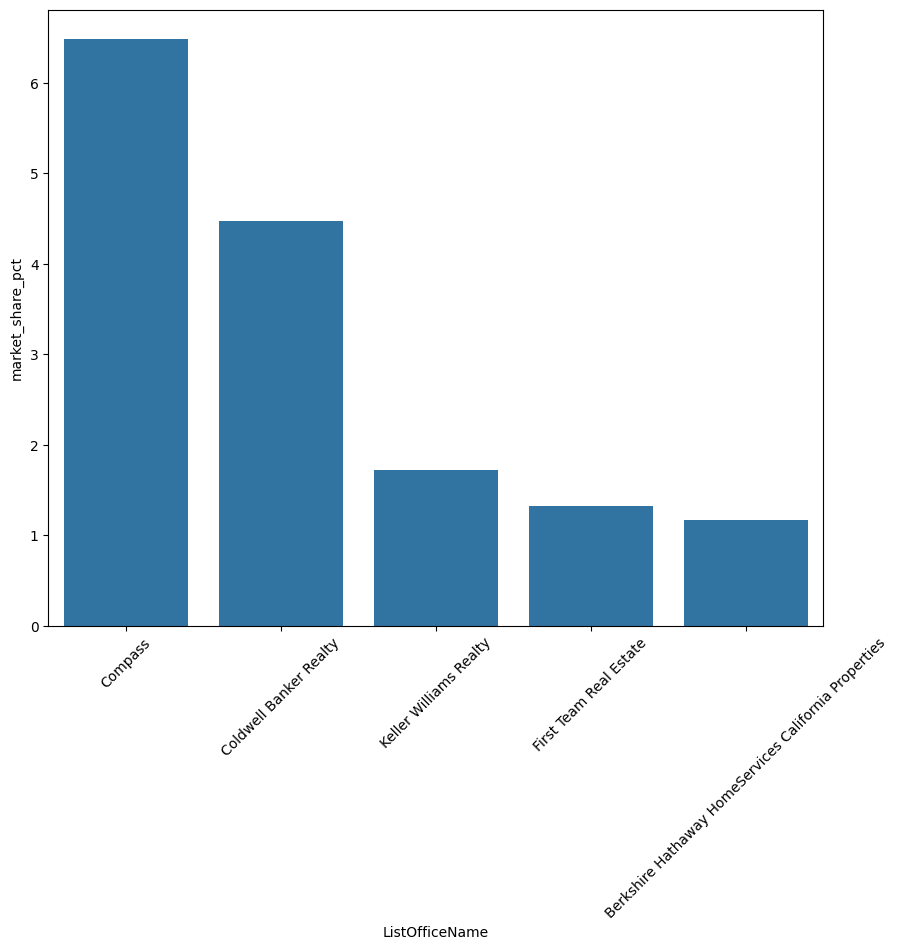

In [283]:
plt.figure(figsize=(10, 8))
sns.barplot(x='ListOfficeName', y='market_share_pct', data=largest_market)
plt.xticks(rotation=45)
plt.show()

B. Premium vs. Discount

In [284]:
listing_office_summary['premium_discount_pct'] = (
    (listing_office_summary['avg_sale_to_list'] - 1) * 100
)

In [285]:
listing_office_summary[listing_office_summary['premium_discount_pct'] < 0].head()

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
6,Berkshire Hathaway HomeServices California Pro...,2541,10172,1.635653e+09,550000.0,20.072847,0.986195,11.0,550000.0,1.635653e+09,1.163243,-1.380536
12,Sotheby's International Realty,1242,5303,8.335063e+08,550000.0,21.887234,0.982974,11.0,550000.0,8.335063e+08,0.568575,-1.702636
14,Redfin Corporation,939,3923,8.178944e+08,775000.0,17.870507,0.992471,11.0,775000.0,8.178944e+08,0.429864,-0.752927
20,Seven Gables Real Estate,943,2662,6.766607e+08,715000.0,15.729151,0.997045,10.0,715000.0,6.766607e+08,0.431696,-0.295547
21,Berkshire Hathaway HomeService,1087,3400,6.434866e+08,425000.0,18.384118,0.995491,10.0,425000.0,6.434866e+08,0.497617,-0.450909


In [286]:
listing_office_summary[listing_office_summary['premium_discount_pct'] > 0].head()

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
0,Compass,14165,51926,1.206265e+10,815000.0,17.915726,1.014110,10.0,815000.0,1.206265e+10,6.484589,1.410977
1,Coldwell Banker Realty,9762,34578,7.286856e+09,700000.0,19.163167,1.013193,11.0,700000.0,7.286856e+09,4.468941,1.319308
2,Keller Williams Realty,3754,12364,2.825281e+09,740000.0,16.712391,1.298099,9.0,740000.0,2.825281e+09,1.718542,29.809916
3,First Team Real Estate,2882,8708,1.914824e+09,650000.0,16.965893,209.275377,10.0,650000.0,1.914824e+09,1.319349,20827.537717
4,Intero Real Estate Services,1543,6744,1.846734e+09,1200000.0,17.179567,1.043353,10.0,1200000.0,1.846734e+09,0.706369,4.335280


In [287]:
largest_premium = listing_office_summary[listing_office_summary['premium_discount_pct'] != float('inf')].nlargest(5, 'premium_discount_pct')

In [288]:
largest_premium

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
5361,Conolan Realty,3,5,2138000.0,805000.0,21.200000,297879.319692,17.0,805000.0,2138000.0,0.001373,2.978783e+07
109,Realty Masters & Associates,249,1097,135949839.0,560000.0,18.201459,3849.718354,11.0,560000.0,135949839.0,0.113990,3.848718e+05
29,KW Advisors East Bay,439,1424,456466640.0,937000.0,17.695225,2256.216807,13.0,937000.0,456466640.0,0.200970,2.255217e+05
7177,Dynamic Real Estate Services,1,6,1400000.0,1400000.0,21.333333,1098.039216,21.0,1400000.0,1400000.0,0.000458,1.097039e+05
10484,Champion Realty,1,24,680000.0,680000.0,14.916667,1000.000000,7.5,680000.0,680000.0,0.000458,9.990000e+04


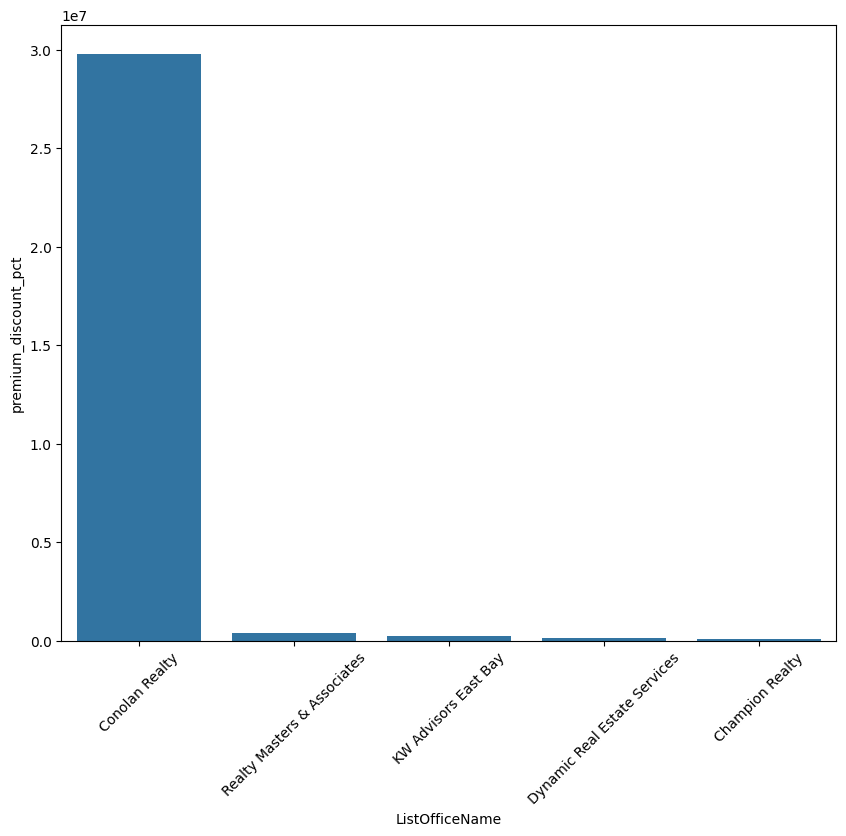

In [289]:
plt.figure(figsize=(10, 8))
sns.barplot(x='ListOfficeName', y='premium_discount_pct', data=largest_premium)
plt.xticks(rotation=45)
plt.show()

In [290]:
smallest_premium = listing_office_summary.nsmallest(5, 'premium_discount_pct')
smallest_premium

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
19274,Elite Realty Agents,1,1,0.00,0.00,1.000000,0.000000,1.0,0.00,0.00,0.000458,-100.000000
15336,"Carl Reinhart, Broker",1,8,18.00,18.00,19.375000,0.000162,13.0,18.00,18.00,0.000458,-99.983772
15337,Altman Apartments LLC,1,9,2.12,2.12,19.666667,0.000356,0.0,2.12,2.12,0.000458,-99.964370
8294,Mayer Makabe,1,3,1100000.00,1100000.00,31.333333,0.000845,15.0,1100000.00,1100000.00,0.000458,-99.915515
15150,Mitigation Land Specialists,1,2,2400.00,2400.00,28.500000,0.000873,28.5,2400.00,2400.00,0.000458,-99.912727


C. Efficiency Score

In [291]:
listing_office_summary['efficiency_score'] = (
    listing_office_summary['avg_sale_to_list']
    / listing_office_summary['median_dom']
)

In [292]:
listing_office_summary[listing_office_summary['efficiency_score'] != float('inf')]['efficiency_score'].describe()

count    15178.000000
mean         1.389150
std        142.277801
min          0.000000
25%          0.064299
50%          0.093313
75%          0.133333
max      17522.312923
Name: efficiency_score, dtype: float64

In [293]:
top_efficiency = (
    listing_office_summary.sort_values(
        by='efficiency_score',
        ascending=False
    )
)

top_efficiency[top_efficiency['efficiency_score'] != float('inf')].nlargest(5, 'efficiency_score')

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct,efficiency_score
5361,Conolan Realty,3,5,2138000.0,805000.0,21.200000,297879.319692,17.0,805000.0,2138000.0,0.001373,2.978783e+07,17522.312923
109,Realty Masters & Associates,249,1097,135949839.0,560000.0,18.201459,3849.718354,11.0,560000.0,135949839.0,0.113990,3.848718e+05,349.974396
29,KW Advisors East Bay,439,1424,456466640.0,937000.0,17.695225,2256.216807,13.0,937000.0,456466640.0,0.200970,2.255217e+05,173.555139
3020,LE INVESTMENT GROUP,7,77,4432500.0,489000.0,17.870130,138.090572,1.0,489000.0,4432500.0,0.003205,1.370906e+04,138.090572
10484,Champion Realty,1,24,680000.0,680000.0,14.916667,1000.000000,7.5,680000.0,680000.0,0.000458,9.990000e+04,133.333333


D. Luxury Brokerage

In [294]:
# Define luxury threshold (top 10%)

luxury_threshold = (
    listings_cleaned_df['ClosePrice']
    .quantile(0.90)
)
luxury_threshold

np.float64(1460000.0)

In [295]:
# Filter luxury listings

luxury_listings = listings_cleaned_df[
    listings_cleaned_df['ClosePrice'] >= luxury_threshold
]
len(luxury_listings)

21884

In [296]:
luxury_office_summary = (
    luxury_listings.groupby('ListOfficeName')
    .agg(
        luxury_sales=('ClosePrice', 'count'),

        avg_luxury_price=('ClosePrice', 'mean'),

        median_luxury_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

In [297]:
luxury_office_summary

,ListOfficeName,luxury_sales,avg_luxury_price,median_luxury_dom
0,1% LISTING FEE,1,2.390000e+06,35.0
1,10-8 Real Estate,1,2.200000e+06,7.0
2,121 Properties Inc,1,2.500000e+06,1.0
3,168 Realty,7,1.585727e+06,8.0
4,168 Realty Inc.,2,1.525000e+06,17.5
...,...,...,...,...
3367,house333,1,2.400000e+06,3.0
3368,iHome Realty,1,1.460000e+06,9.0
3369,iPro Real Estate,2,2.405000e+06,3.0
3370,reframe,1,1.530000e+06,6.0


In [298]:
# Keep offices with enough luxury transactions

luxury_office_summary = luxury_office_summary[
    luxury_office_summary['luxury_sales'] >= 5
]

print("\nTOP LUXURY OFFICES")
print(
    luxury_office_summary.sort_values(
        by='luxury_sales',
        ascending=False
    ).head(10)
)


TOP LUXURY OFFICES
                                         ListOfficeName  luxury_sales  \
714                                             Compass          3181   
698                              Coldwell Banker Realty          1750   
1414                        Intero Real Estate Services           541   
1609                             Keller Williams Realty           427   
2961                                         The Agency           354   
328   Berkshire Hathaway HomeServices California Pro...           342   
1085                             First Team Real Estate           340   
2476                                        Real Broker           259   
624         Christie's International Real Estate Sereno           257   
1001                                       Equity Union           231   

      avg_luxury_price  median_luxury_dom  
714       1.910967e+06                9.0  
698       1.882684e+06                9.0  
1414      1.858805e+06                8.0  


In [299]:
largest_luxury = luxury_office_summary.nlargest(5, 'luxury_sales')

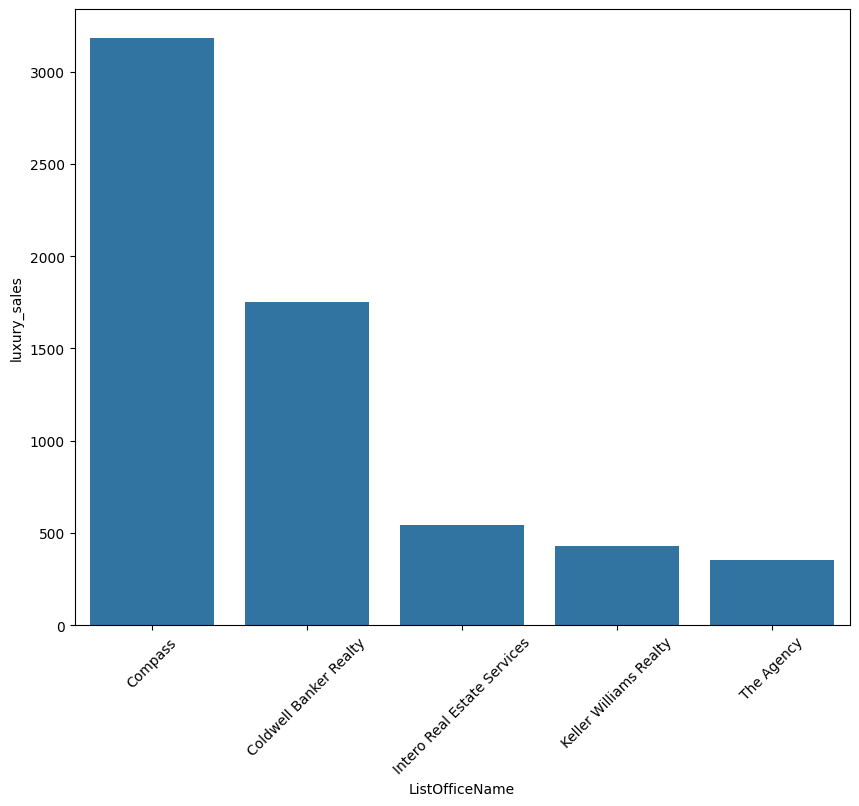

In [300]:
plt.figure(figsize=(10, 8))
sns.barplot(x='ListOfficeName', y='luxury_sales', data=largest_luxury)
plt.xticks(rotation=45)
plt.show()

E. Geographic Specialization

In [301]:
office_geo_summary = (
    listings_cleaned_df.groupby(
        ['ListOfficeName', 'MLSAreaMajor']
    )
    .agg(
        sales_count=('ClosePrice', 'count'),

        avg_close_price=('ClosePrice', 'mean'),

        median_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

print("\nOFFICE GEOGRAPHIC SPECIALIZATION")
print(office_geo_summary.head())


OFFICE GEOGRAPHIC SPECIALIZATION
               ListOfficeName                        MLSAreaMajor  \
0  #1 FLAT FEE-LIBERTY REALTY                   682 - Chino Hills   
1           #1 Home SalesÃÂ®                     252 - Riverside   
2           #1 Home SalesÃÂ®  SRCAR - Southwest Riverside County   
3        #1 Realty Homes Inc.             322 - North Palm Desert   
4        #1 Realty Homes Inc.          335 - Cathedral City North   

   sales_count  avg_close_price  median_dom  
0            1         945000.0        16.0  
1            0              NaN        16.0  
2            0              NaN         2.0  
3            0              NaN         2.0  
4            0              NaN        53.5  


In [302]:
office_geo_summary.nlargest(5, 'avg_close_price')

,ListOfficeName,MLSAreaMajor,sales_count,avg_close_price,median_dom
173847,Wedgewood Homes Realty,N7 - West Bay - Santa Ana Heights,1,2540500.0,5.0
59871,GM Realty,92075 - Solana Beach,1,2540000.0,36.0
152174,Sotheby's International Realty,MCTO - Montecito,1,2538880.0,8.0
18427,Big Sur Inc.,699 - Not Defined,1,2538500.0,7.0
162545,The Oppenheim Group,73 - Villa Park,1,2533650.0,58.0


In [303]:
office_geo_summary.nlargest(5, 'sales_count')

,ListOfficeName,MLSAreaMajor,sales_count,avg_close_price,median_dom
39178,Compass,Missing,2607,1.163660e+06,10.0
38836,Compass,699 - Not Defined,1677,1.213618e+06,10.0
37006,Coldwell Banker Realty,699 - Not Defined,1611,1.184718e+06,10.0
73944,Intero Real Estate Services,699 - Not Defined,1122,1.249897e+06,10.0
37311,Coldwell Banker Realty,Missing,846,1.092694e+06,10.0


F. Property Type Specialization

In [304]:
office_property_summary = (
    listings_cleaned_df.groupby(
        ['ListOfficeName', 'PropertyType']
    )
    .agg(
        sales_count=('ClosePrice', 'count'),

        avg_close_price=('ClosePrice', 'mean'),

        median_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

print("\nOFFICE PROPERTY TYPE SPECIALIZATION")
print(office_property_summary.head())


OFFICE PROPERTY TYPE SPECIALIZATION
               ListOfficeName        PropertyType  sales_count  \
0  #1 FLAT FEE-LIBERTY REALTY         Residential            1   
1           #1 Home SalesÃÂ®         Residential            0   
2        #1 Realty Homes Inc.         Residential            0   
3        #1 Realty Homes Inc.    ResidentialLease            0   
4                           *  ManufacturedInPark            0   

   avg_close_price  median_dom  
0         945000.0        16.0  
1              NaN         3.0  
2              NaN         5.0  
3              NaN         8.0  
4              NaN         1.5  


In [305]:
office_property_summary.nlargest(5, 'avg_close_price')

,ListOfficeName,PropertyType,sales_count,avg_close_price,median_dom
5153,Big Sur Inc.,Residential,1,2538500.0,7.0
33448,REB COMPANY,Residential,1,2531434.0,0.0
5186,Billionaires Row,ResidentialIncome,1,2525000.0,50.0
12565,ENGEL & VÃÂLKERS Santa Monica,ResidentialIncome,1,2525000.0,20.0
20537,Jesse Weinberg,CommercialSale,1,2525000.0,2.0


In [306]:
office_property_summary.nlargest(5, 'sales_count')

,ListOfficeName,PropertyType,sales_count,avg_close_price,median_dom
9891,Compass,Residential,9283,1.242377e+06,11.0
9634,Coldwell Banker Realty,Residential,5913,1.172505e+06,11.0
9893,Compass,ResidentialLease,4424,6.764877e+03,9.0
9636,Coldwell Banker Realty,ResidentialLease,3480,5.493944e+03,10.0
22231,Keller Williams Realty,Residential,2762,9.748918e+05,9.0


G. Office Tier Classification

In [307]:
def classify_office(row):

    if row['sales_count'] > 500:
        return 'High Volume'

    elif row['median_close_price'] > 1000000:
        return 'Luxury Specialist'

    elif row['efficiency_score'] > 0.02:
        return 'High Efficiency'

    else:
        return 'Standard'


listing_office_summary['office_category'] = (
    listing_office_summary.apply(classify_office, axis=1)
)

print("\nOFFICE CATEGORIES")
print(
    listing_office_summary[
        ['ListOfficeName', 'office_category']
    ].head(20)
)


OFFICE CATEGORIES
                                       ListOfficeName office_category
0                                             Compass     High Volume
1                              Coldwell Banker Realty     High Volume
2                              Keller Williams Realty     High Volume
3                              First Team Real Estate     High Volume
4                         Intero Real Estate Services     High Volume
5                                         Real Broker     High Volume
6   Berkshire Hathaway HomeServices California Pro...     High Volume
7                        eXp Realty of California Inc     High Volume
8                                        Equity Union     High Volume
9                      eXp Realty of California, Inc.     High Volume
10                                         The Agency     High Volume
11                               Coldwell Banker West     High Volume
12                     Sotheby's International Realty     High Volume
1

H. Competitive Positioning

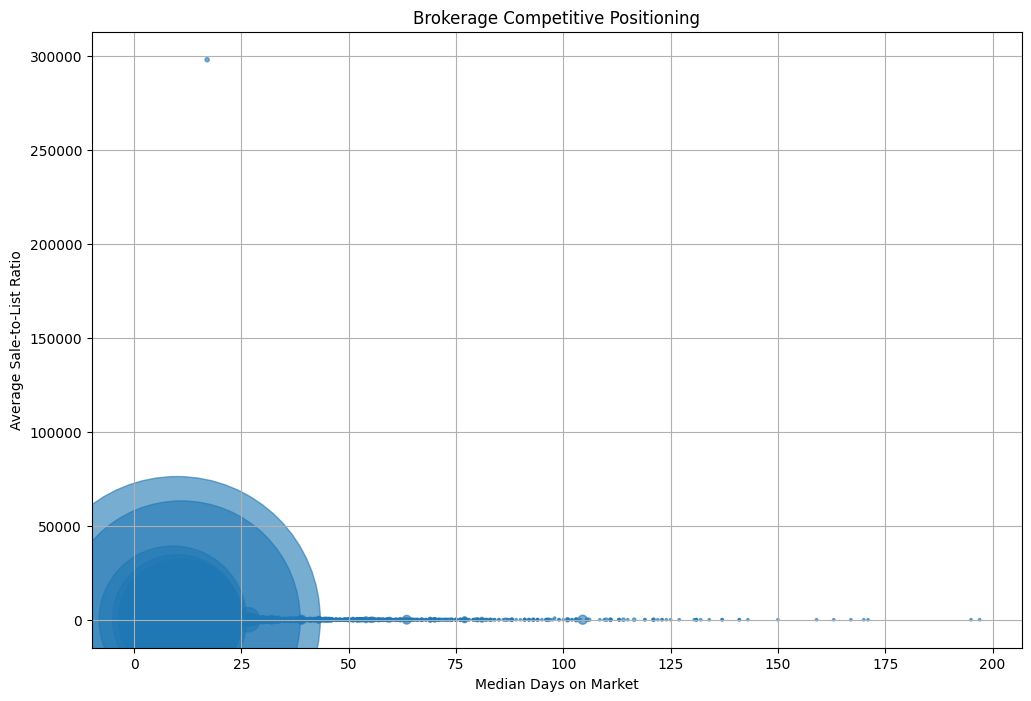

In [308]:
plt.figure(figsize=(12, 8))

plt.scatter(
    listing_office_summary['median_dom'],
    listing_office_summary['avg_sale_to_list'],

    s=listing_office_summary['sales_count'] * 3,

    alpha=0.6
)

plt.xlabel('Median Days on Market')
plt.ylabel('Average Sale-to-List Ratio')

plt.title('Brokerage Competitive Positioning')

plt.grid(True)

plt.show()

I. Top 10 Offices by Sales Volume

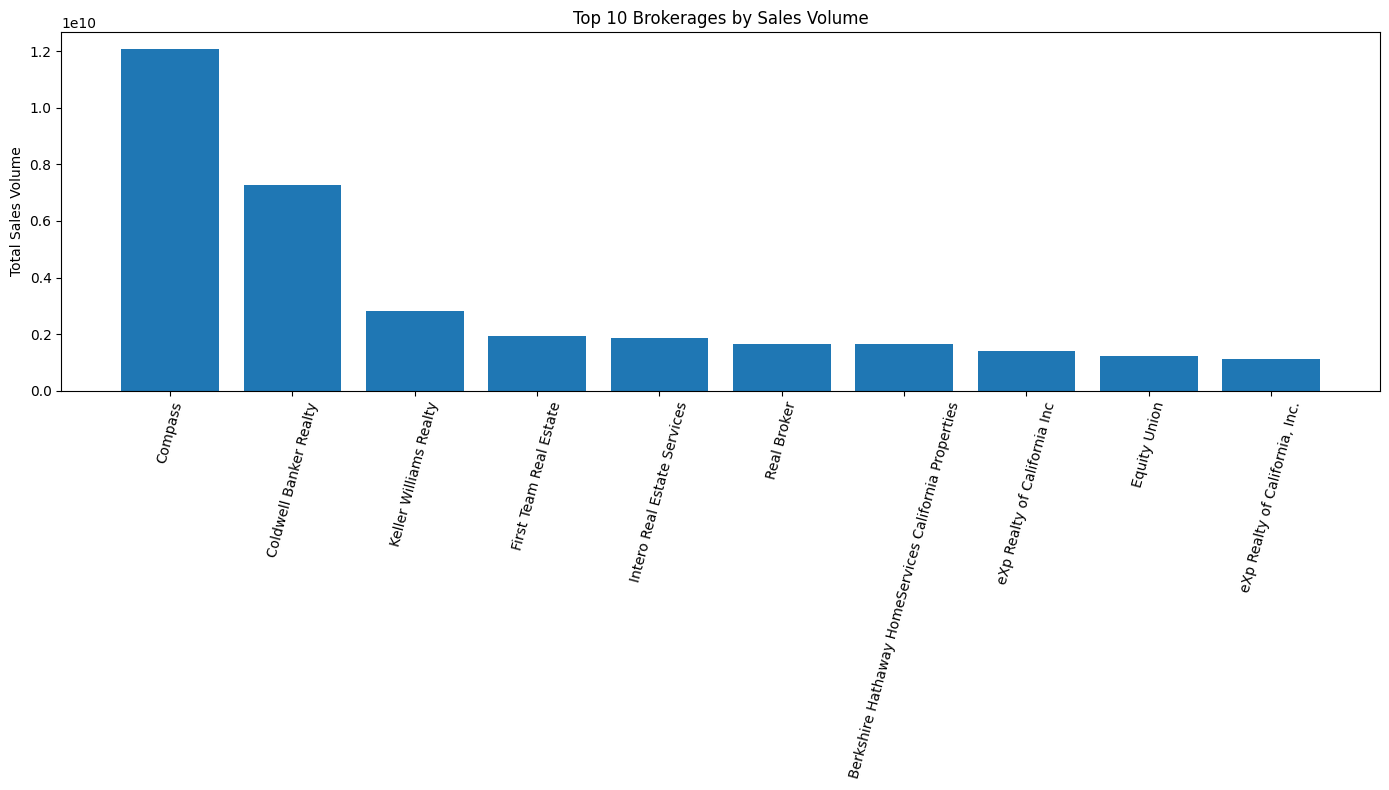

In [309]:
top_volume = (
    listing_office_summary.sort_values(
        by='total_sales_volume',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(14, 8))

plt.bar(
    top_volume['ListOfficeName'],
    top_volume['total_sales_volume']
)

plt.xticks(rotation=75)

plt.ylabel('Total Sales Volume')

plt.title('Top 10 Brokerages by Sales Volume')

plt.tight_layout()

plt.show()

BuyerOfficeName

In [310]:
buyer_office_summary = (
    listings_cleaned_df.groupby('BuyerOfficeName')
    .agg(
        listings=('ListingId', 'count'),
        total_volume=('ClosePrice', 'sum'),
        median_sale_price=('ClosePrice', 'median'),
        avg_dom=('DaysOnMarket', 'mean'),
        avg_sale_to_list=('price_ratio', 'mean'),
        sales_count=('ClosePrice', 'count'),
        median_dom=('DaysOnMarket', 'median'),
        median_close_price=('ClosePrice', 'median'),
        total_sales_volume=('ClosePrice', 'sum')
    )
    .sort_values('total_volume', ascending=False)
    .reset_index()
)

In [311]:
buyer_office_summary[buyer_office_summary.notna()].head()

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume
0,Compass,15210,1.133079e+10,810000.0,21.265812,1.228235,13567,12.0,810000.0,1.133079e+10
1,Coldwell Banker Realty,8808,5.762703e+09,610000.0,22.351953,1.115909,8307,12.0,610000.0,5.762703e+09
2,Keller Williams Realty,3564,2.125162e+09,665000.0,20.325758,1.010961,3148,11.0,665000.0,2.125162e+09
3,Real Broker,3057,2.104872e+09,675000.0,24.620216,1.342506,2964,14.0,675000.0,2.104872e+09
4,NONMEMBER MRML,4141,1.769954e+09,398800.0,28.845448,inf,4108,17.0,398800.0,1.769954e+09


A. Brokerage Performance

In [312]:
buyer_office_summary['avg_sale_to_list'].describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.596700e+04
mean              inf
std               NaN
min      0.000000e+00
25%      9.683346e-01
50%      9.937107e-01
75%      1.008572e+00
max               inf
Name: avg_sale_to_list, dtype: float64

In [313]:
buyer_office_summary[buyer_office_summary['avg_sale_to_list'] != float('inf')].nlargest(10, 'avg_sale_to_list')

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume
7040,Sonnek Realty,5,1.526350e+06,4750.0,14.400000,120000.792547,5,16.0,4750.0,1.526350e+06
963,REALTY ONE GROUP HOMELINK,29,1.554895e+07,560000.0,26.758621,34483.709255,29,17.0,560000.0,1.554895e+07
325,Christie's AKG,95,5.173771e+07,15350.0,20.673684,9507.750187,94,14.0,15350.0,5.173771e+07
104,Realty Masters & Associates,246,1.421366e+08,559950.0,23.162602,3896.662252,246,13.0,559950.0,1.421366e+08
39,KW Advisors East Bay,602,3.582658e+08,1001000.0,18.197674,2959.579263,335,13.0,1001000.0,3.582658e+08
7100,GOLDEN INFINITY GROUP,2,1.509500e+06,754750.0,10.500000,1575.460251,2,10.5,754750.0,1.509500e+06
9959,Pickford Real Estate Inc,1,8.400000e+05,840000.0,21.000000,1001.191895,1,21.0,840000.0,8.400000e+05
5294,"Thompson Team Real Estate, Inc",1,2.250000e+06,2250000.0,20.000000,1000.000000,1,20.0,2250000.0,2.250000e+06
10999,"Equinox Real Estate Group, Inc.",1,6.800000e+05,680000.0,0.000000,1000.000000,1,0.0,680000.0,6.800000e+05
12,Equity Union,1807,1.029477e+09,503000.0,28.919757,999.410154,1805,19.0,503000.0,1.029477e+09


In [314]:
buyer_office_summary['market_share_pct'] = (
    buyer_office_summary['sales_count']
    / buyer_office_summary['sales_count'].sum()
) * 100

In [315]:
avg_market = buyer_office_summary.groupby('BuyerOfficeName')['market_share_pct'].mean().reset_index()
avg_market.head()

,BuyerOfficeName,market_share_pct
0,& Company Real Estate,0.000462
1,*,0.001387
2,", Inc",0.000462
3,1,0.000462
4,1 Percent Lists Desert 2 Coast,0.000462


In [316]:
buyer_office_summary.nlargest(5, 'market_share_pct')

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct
0,Compass,15210,1.133079e+10,810000.0,21.265812,1.228235,13567,12.0,810000.0,1.133079e+10,6.272191
1,Coldwell Banker Realty,8808,5.762703e+09,610000.0,22.351953,1.115909,8307,12.0,610000.0,5.762703e+09,3.840428
18,None MRML,4821,6.327962e+08,3900.0,25.786351,0.990247,4821,16.0,3900.0,6.327962e+08,2.228808
4,NONMEMBER MRML,4141,1.769954e+09,398800.0,28.845448,inf,4108,17.0,398800.0,1.769954e+09,1.899179
2,Keller Williams Realty,3564,2.125162e+09,665000.0,20.325758,1.010961,3148,11.0,665000.0,2.125162e+09,1.455359


In [317]:
largest_market = avg_market.nlargest(5, 'market_share_pct')
largest_market

,BuyerOfficeName,market_share_pct
3556,Compass,6.272191
3468,Coldwell Banker Realty,3.840428
10166,None MRML,2.228808
9815,NONMEMBER MRML,1.899179
7842,Keller Williams Realty,1.455359


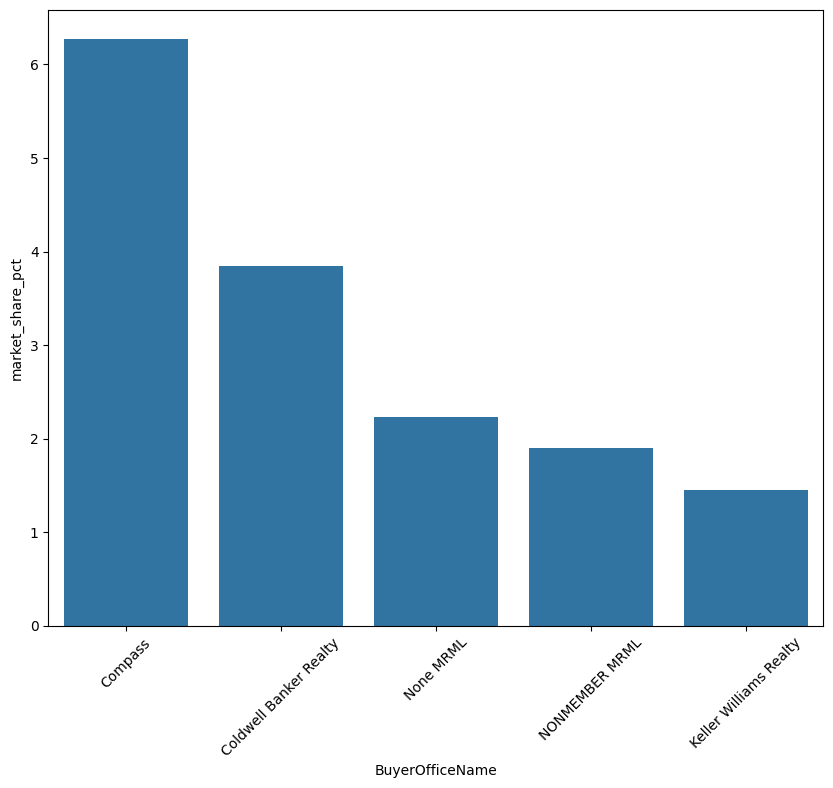

In [318]:
plt.figure(figsize=(10, 8))
sns.barplot(x='BuyerOfficeName', y='market_share_pct', data=largest_market)
plt.xticks(rotation=45)
plt.show()

B. Premium vs. Discount

In [319]:
buyer_office_summary['premium_discount_pct'] = (
    (buyer_office_summary['avg_sale_to_list'] - 1) * 100
)

In [320]:
buyer_office_summary[buyer_office_summary['premium_discount_pct'] < 0].head()

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
9,Berkshire Hathaway HomeServices California Pro...,2075,1.294709e+09,502500.0,24.802892,0.986671,2072,14.0,502500.0,1.294709e+09,0.957911,-1.332922
11,Redfin Corporation,1238,1.127774e+09,840000.0,24.437803,0.996186,1218,13.0,840000.0,1.127774e+09,0.563096,-0.381352
17,Sotheby's International Realty,1183,6.849648e+08,22000.0,26.107354,0.989059,1165,15.0,22000.0,6.849648e+08,0.538594,-1.094076
18,None MRML,4821,6.327962e+08,3900.0,25.786351,0.990247,4821,16.0,3900.0,6.327962e+08,2.228808,-0.975334
20,Seven Gables Real Estate,828,5.608931e+08,655500.0,19.187198,0.995570,828,11.0,655500.0,5.608931e+08,0.382795,-0.442993


In [321]:
buyer_office_summary[buyer_office_summary['premium_discount_pct'] > 0].head()

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
0,Compass,15210,1.133079e+10,810000.0,21.265812,1.228235,13567,12.0,810000.0,1.133079e+10,6.272191,22.823511
1,Coldwell Banker Realty,8808,5.762703e+09,610000.0,22.351953,1.115909,8307,12.0,610000.0,5.762703e+09,3.840428,11.590885
2,Keller Williams Realty,3564,2.125162e+09,665000.0,20.325758,1.010961,3148,11.0,665000.0,2.125162e+09,1.455359,1.096092
3,Real Broker,3057,2.104872e+09,675000.0,24.620216,1.342506,2964,14.0,675000.0,2.104872e+09,1.370294,34.250566
4,NONMEMBER MRML,4141,1.769954e+09,398800.0,28.845448,inf,4108,17.0,398800.0,1.769954e+09,1.899179,inf


In [322]:
largest_premium = buyer_office_summary[buyer_office_summary['premium_discount_pct'] != float('inf')].nlargest(5, 'premium_discount_pct')
largest_premium

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
7040,Sonnek Realty,5,1.526350e+06,4750.0,14.400000,120000.792547,5,16.0,4750.0,1.526350e+06,0.002312,1.199998e+07
963,REALTY ONE GROUP HOMELINK,29,1.554895e+07,560000.0,26.758621,34483.709255,29,17.0,560000.0,1.554895e+07,0.013407,3.448271e+06
325,Christie's AKG,95,5.173771e+07,15350.0,20.673684,9507.750187,94,14.0,15350.0,5.173771e+07,0.043457,9.506750e+05
104,Realty Masters & Associates,246,1.421366e+08,559950.0,23.162602,3896.662252,246,13.0,559950.0,1.421366e+08,0.113729,3.895662e+05
39,KW Advisors East Bay,602,3.582658e+08,1001000.0,18.197674,2959.579263,335,13.0,1001000.0,3.582658e+08,0.154875,2.958579e+05


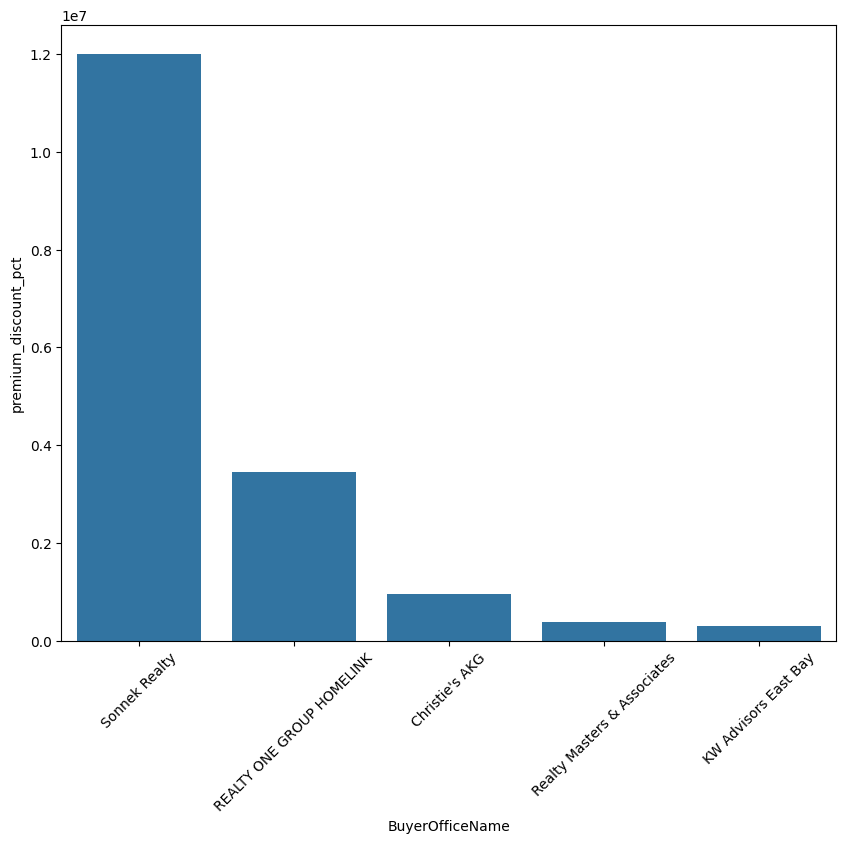

In [323]:
plt.figure(figsize=(10, 8))
sns.barplot(x='BuyerOfficeName', y='premium_discount_pct', data=largest_premium)
plt.xticks(rotation=45)
plt.show()

In [324]:
smallest_premium = buyer_office_summary.nsmallest(5, 'premium_discount_pct')
smallest_premium

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
16127,C21 Realty Masters,1,0.00,0.00,25.0,0.000000,1,25.0,0.00,0.00,0.000462,-100.000000
16394,Elite Realty Agents,1,0.00,0.00,1.0,0.000000,1,1.0,0.00,0.00,0.000462,-100.000000
15964,Altman Apartments LLC,1,2.12,2.12,96.0,0.000356,1,96.0,2.12,2.12,0.000462,-99.964370
15772,Mitigation Land Specialists,1,2400.00,2400.00,57.0,0.000873,1,57.0,2400.00,2400.00,0.000462,-99.912727
15598,"Scott Voak, Broker",1,2900.00,2900.00,44.0,0.000906,1,44.0,2900.00,2900.00,0.000462,-99.909375


C. Efficiency Score

In [325]:
buyer_office_summary['efficiency_score'] = (
    buyer_office_summary['avg_sale_to_list']
    / buyer_office_summary['median_dom']
)

In [326]:
buyer_office_summary[buyer_office_summary['efficiency_score'] != float('inf')]['efficiency_score'].describe()

count    15597.000000
mean         0.827266
std         62.538214
min          0.000000
25%          0.037313
50%          0.068311
75%          0.113541
max       7500.049534
Name: efficiency_score, dtype: float64

In [327]:
top_efficiency = (
    buyer_office_summary.sort_values(
        by='efficiency_score',
        ascending=False
    )
)


In [328]:
top_efficiency[top_efficiency['efficiency_score'] != float('inf')].nlargest(5, 'efficiency_score')

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct,efficiency_score
7040,Sonnek Realty,5,1.526350e+06,4750.0,14.400000,120000.792547,5,16.0,4750.0,1.526350e+06,0.002312,1.199998e+07,7500.049534
963,REALTY ONE GROUP HOMELINK,29,1.554895e+07,560000.0,26.758621,34483.709255,29,17.0,560000.0,1.554895e+07,0.013407,3.448271e+06,2028.453486
325,Christie's AKG,95,5.173771e+07,15350.0,20.673684,9507.750187,94,14.0,15350.0,5.173771e+07,0.043457,9.506750e+05,679.125013
104,Realty Masters & Associates,246,1.421366e+08,559950.0,23.162602,3896.662252,246,13.0,559950.0,1.421366e+08,0.113729,3.895662e+05,299.743250
39,KW Advisors East Bay,602,3.582658e+08,1001000.0,18.197674,2959.579263,335,13.0,1001000.0,3.582658e+08,0.154875,2.958579e+05,227.659943


D. Luxury Brokerage

In [329]:
# Define luxury threshold (top 10%)

luxury_threshold = (
    listings_cleaned_df['ClosePrice']
    .quantile(0.90)
)
luxury_threshold


np.float64(1460000.0)

In [330]:
# Filter luxury listings

luxury_listings = listings_cleaned_df[
    listings_cleaned_df['ClosePrice'] >= luxury_threshold
]
len(luxury_listings)

luxury_office_summary = (
    luxury_listings.groupby('BuyerOfficeName')
    .agg(
        luxury_sales=('ClosePrice', 'count'),

        avg_luxury_price=('ClosePrice', 'mean'),

        median_luxury_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

luxury_office_summary

,BuyerOfficeName,luxury_sales,avg_luxury_price,median_luxury_dom
0,", Inc",1,2225000.0,4.0
1,1 Percent Lists SoCal,1,2325000.0,6.0
2,1031 Exchange Group,1,2138000.0,10.0
3,121 Properties Inc,1,1549000.0,39.0
4,168 Realty,5,1697644.4,10.0
...,...,...,...,...
3791,"i2i Real Estate and Mortgage,",1,1499000.0,37.0
3792,iHome Realty,3,1900000.0,26.0
3793,iResidential Real Estate,1,2300000.0,2.0
3794,kw pacific estates,1,2368880.0,18.0


In [331]:
# Keep offices with enough luxury transactions

luxury_office_summary = luxury_office_summary[
    luxury_office_summary['luxury_sales'] >= 5
]

print("\nTOP LUXURY OFFICES")
print(
    luxury_office_summary.sort_values(
        by='luxury_sales',
        ascending=False
    ).head(10)
)


TOP LUXURY OFFICES
                                        BuyerOfficeName  luxury_sales  \
826                                             Compass          2960   
803                              Coldwell Banker Realty          1398   
1578                        Intero Real Estate Services           453   
1799                             Keller Williams Realty           308   
2882                                             Redfin           300   
2786                                        Real Broker           279   
1219                             First Team Real Estate           272   
390   Berkshire Hathaway HomeServices California Pro...           269   
3332                                         The Agency           264   
3768                       eXp Realty of California Inc           239   

      avg_luxury_price  median_luxury_dom  
826       1.905016e+06                9.0  
803       1.883806e+06                9.0  
1578      1.867087e+06                7.0  


In [332]:
largest_luxury = luxury_office_summary.nlargest(5, 'luxury_sales')

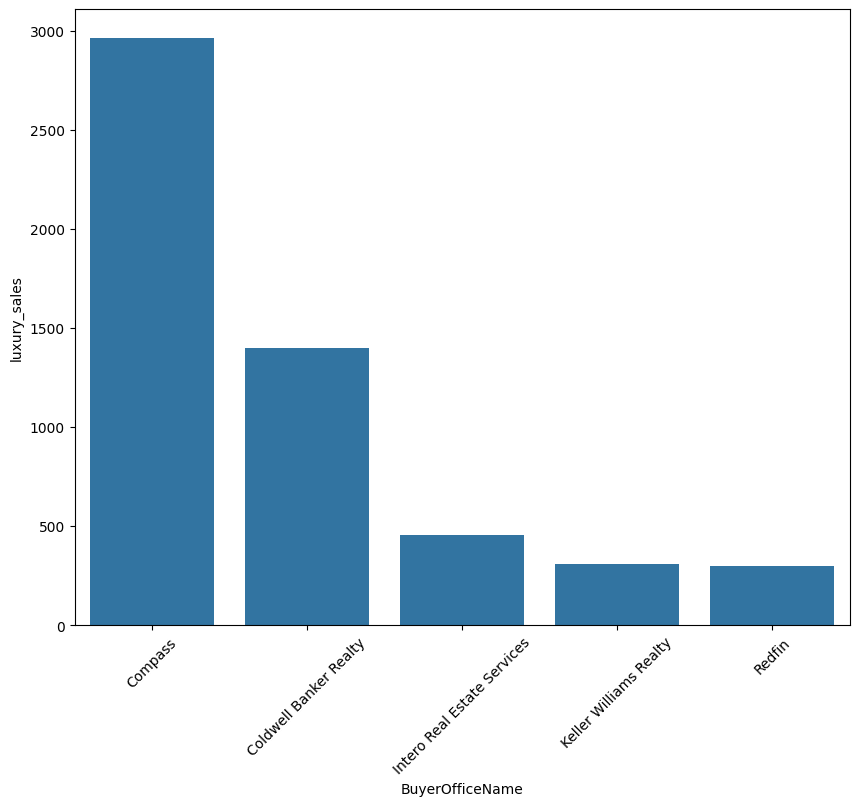

In [333]:
plt.figure(figsize=(10, 8))
sns.barplot(x='BuyerOfficeName', y='luxury_sales', data=largest_luxury)
plt.xticks(rotation=45)
plt.show()

E. Geographic Specialization

In [334]:
office_geo_summary = (
    listings_cleaned_df.groupby(
        ['BuyerOfficeName', 'MLSAreaMajor']
    )
    .agg(
        sales_count=('ClosePrice', 'count'),

        avg_close_price=('ClosePrice', 'mean'),

        median_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

print("\nOFFICE GEOGRAPHIC SPECIALIZATION")
print(office_geo_summary.head())


OFFICE GEOGRAPHIC SPECIALIZATION
         BuyerOfficeName                           MLSAreaMajor  sales_count  \
0  & Company Real Estate                       AV - Aliso Viejo            1   
1                      *  6 - Bixby, Bixby Knolls, Los Cerritos            1   
2                      *                      699 - Not Defined            1   
3                      *                   7 - North Long Beach            1   
4                  , Inc          NV - East Bluff - Harbor View            1   

   avg_close_price  median_dom  
0           3500.0         6.0  
1         730000.0         6.0  
2         865000.0        85.0  
3           3500.0        15.0  
4        2225000.0         4.0  


In [335]:
office_geo_summary.nlargest(5, 'avg_close_price')

,BuyerOfficeName,MLSAreaMajor,sales_count,avg_close_price,median_dom
48869,Nourmand & Associates-HW,WP - Westpark,1,2542000.0,26.0
7180,Berkshire Hathaway HomeServices California Pro...,MCTO - Montecito,1,2538880.0,2.0
11111,CQT Paradigm Goup Inc.,OH - Orchard Hills,1,2538000.0,3.0
56326,RE/MAX Estate Properties,170 - West Palos Verdes,1,2538000.0,9.0
39834,"Kott & Company, Inc.",73 - Villa Park,1,2533650.0,58.0


In [336]:
office_geo_summary.nlargest(5, 'sales_count')

,BuyerOfficeName,MLSAreaMajor,sales_count,avg_close_price,median_dom
17757,Compass,Missing,2226,1.170940e+06,11.0
17502,Compass,699 - Not Defined,1342,1.230158e+06,8.0
16385,Coldwell Banker Realty,699 - Not Defined,1157,1.143887e+06,9.0
45968,NONMEMBER MRML,Missing,880,4.439548e+05,15.0
32294,Intero Real Estate Services,699 - Not Defined,816,1.223915e+06,8.0


F. Property Type Specialization

In [337]:
office_property_summary = (
    listings_cleaned_df.groupby(
        ['BuyerOfficeName', 'PropertyType']
    )
    .agg(
        sales_count=('ClosePrice', 'count'),

        avg_close_price=('ClosePrice', 'mean'),

        median_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)
print("\nOFFICE PROPERTY TYPE SPECIALIZATION")
print(office_property_summary.head())


OFFICE PROPERTY TYPE SPECIALIZATION
         BuyerOfficeName      PropertyType  sales_count  avg_close_price  \
0  & Company Real Estate  ResidentialLease            1           3500.0   
1                      *       Residential            2         797500.0   
2                      *  ResidentialLease            1           3500.0   
3                  , Inc       Residential            1        2225000.0   
4                      1       Residential            1         895000.0   

   median_dom  
0         6.0  
1        45.5  
2        15.0  
3         4.0  
4        12.0  


In [338]:
office_property_summary.nlargest(5, 'avg_close_price')

,BuyerOfficeName,PropertyType,sales_count,avg_close_price,median_dom
14374,Modern Homes Realty,Residential,1,2537500.0,66.0
7352,"Erealty & Loans, Inc",Residential,1,2530000.0,0.0
7796,Farzaneh Hakimi,Residential,1,2530000.0,20.0
19334,Richard Ricasata,Residential,1,2530000.0,7.0
1402,Anvil Real Estate,ResidentialIncome,1,2525000.0,0.0


In [339]:
office_property_summary.nlargest(5, 'sales_count')

,BuyerOfficeName,PropertyType,sales_count,avg_close_price,median_dom
5395,Compass,Residential,8728,1.246266e+06,11.0
5239,Coldwell Banker Realty,Residential,4682,1.173803e+06,10.0
5397,Compass,ResidentialLease,4444,6.878659e+03,15.0
15286,None MRML,ResidentialLease,3958,3.911211e+03,16.0
5241,Coldwell Banker Realty,ResidentialLease,3341,5.393154e+03,14.0


G. Office Tier Classification

In [340]:
def classify_office(row):

    if row['sales_count'] > 500:
        return 'High Volume'

    elif row['median_close_price'] > 1000000:
        return 'Luxury Specialist'

    elif row['efficiency_score'] > 0.02:
        return 'High Efficiency'

    else:
        return 'Standard'


buyer_office_summary['office_category'] = (
    buyer_office_summary.apply(classify_office, axis=1)
)

print("\nOFFICE CATEGORIES")
print(
    buyer_office_summary[
        ['BuyerOfficeName', 'office_category']
    ].head(20)
)



OFFICE CATEGORIES
                                      BuyerOfficeName    office_category
0                                             Compass        High Volume
1                              Coldwell Banker Realty        High Volume
2                              Keller Williams Realty        High Volume
3                                         Real Broker        High Volume
4                                      NONMEMBER MRML        High Volume
5                              First Team Real Estate        High Volume
6                        eXp Realty of California Inc        High Volume
7                         Intero Real Estate Services        High Volume
8                      eXp Realty of California, Inc.        High Volume
9   Berkshire Hathaway HomeServices California Pro...        High Volume
10                                             Redfin        High Volume
11                                 Redfin Corporation        High Volume
12                              

H. Competitive Positioning

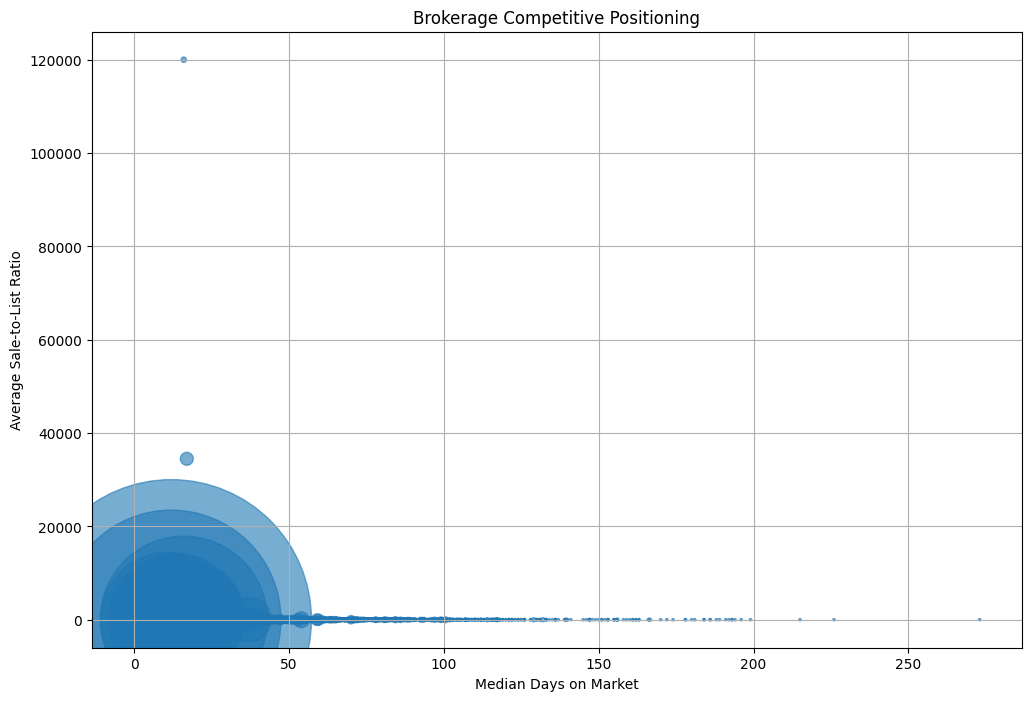

In [341]:
plt.figure(figsize=(12, 8))

plt.scatter(
    buyer_office_summary['median_dom'],
    buyer_office_summary['avg_sale_to_list'],

    s=buyer_office_summary['sales_count'] * 3,

    alpha=0.6
)

plt.xlabel('Median Days on Market')
plt.ylabel('Average Sale-to-List Ratio')

plt.title('Brokerage Competitive Positioning')

plt.grid(True)

plt.show()

I. Top 10 Offices by Sales Volume

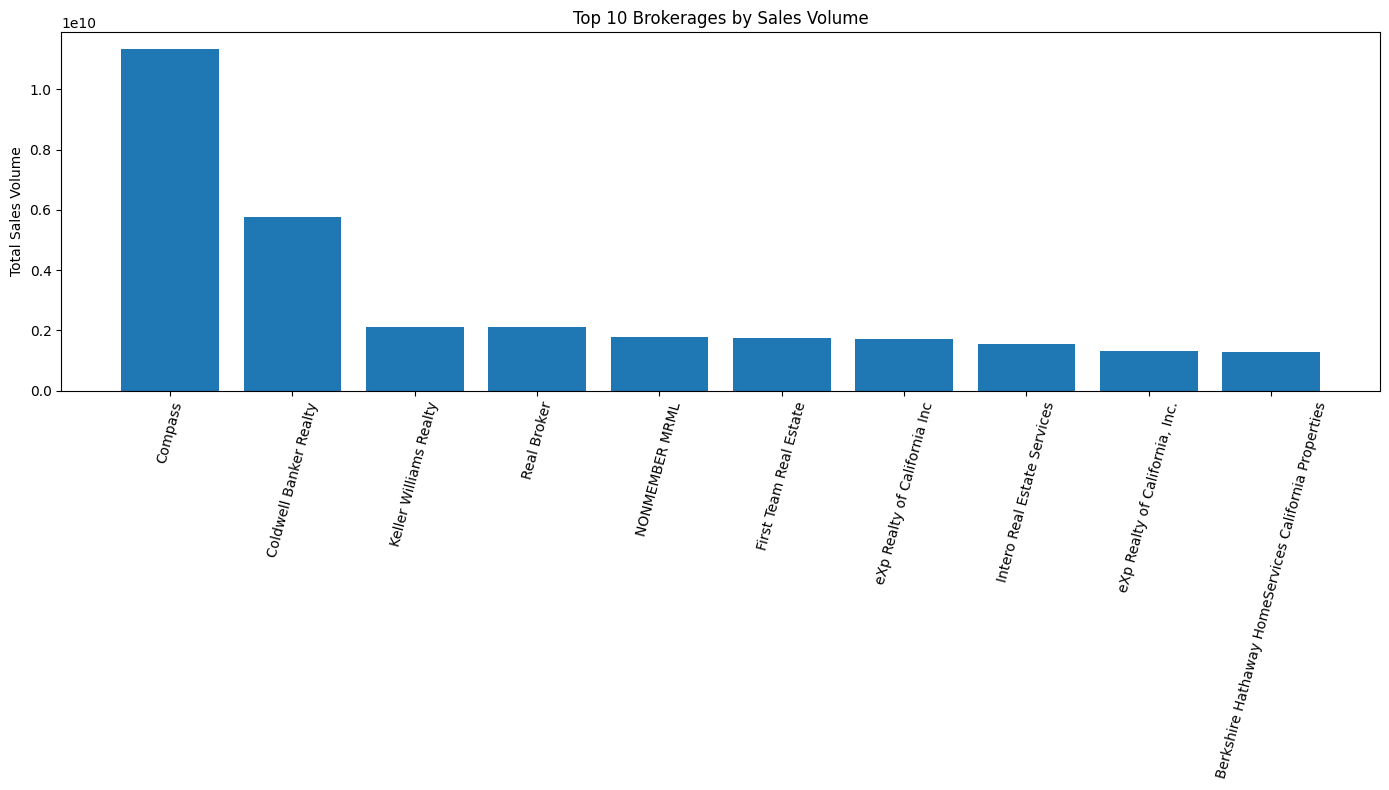

In [342]:
top_volume = (
    buyer_office_summary.sort_values(
        by='total_sales_volume',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(14, 8))

plt.bar(
    top_volume['BuyerOfficeName'],
    top_volume['total_sales_volume']
)

plt.xticks(rotation=75)

plt.ylabel('Total Sales Volume')

plt.title('Top 10 Brokerages by Sales Volume')

plt.tight_layout()

plt.show()

In [343]:
listings_cleaned_df.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'LotSizeSquareFeet', 'Year', 'missing_coordinates_flag',
       'sentinel_null_flag', 'positive_longitude_flag'

In [345]:
#listings_cleaned_df.to_csv("../data/Listing/listings_cleaned_df.csv", index=False)